# Model Comparison

Brings together the saved results from `03_classical_models.ipynb` and
`04_deep_learning_ann.ipynb` — nothing is retrained here, this notebook only reads
`outputs/results/model_metrics.json` and builds the final comparison table and chart for the
"Model Performance Evaluation" section of the presentation.

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from helpers.nb_utils import load_all_metrics, FIG_DIR

pd.set_option("display.max_columns", 50)

## 1. All four models, side by side

In [2]:
results = pd.DataFrame(load_all_metrics().values()).set_index("model")
MODEL_ORDER = ["Decision Tree", "Random Forest", "Naive Bayes", "Multilayer ANN"]
results = results.reindex(MODEL_ORDER)
display(results.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Decision Tree,0.439,0.455,0.441,0.446,0.448,0.439,0.442
Random Forest,0.421,0.437,0.437,0.426,0.430,0.421,0.415
Naive Bayes,0.389,0.539,0.437,0.318,0.554,0.389,0.283
Multilayer ANN,0.321,0.312,0.304,0.294,0.326,0.321,0.312


## 2. Chart for the presentation

Accuracy and macro-F1 side by side — macro-F1 matters here specifically because, as
`02_eda_feature_selection.ipynb` showed, the test set isn't perfectly class-balanced, so accuracy
alone could look reasonable while quietly hiding a model (Naive Bayes, in this project's results)
that almost never predicts the "Medium" class at all.

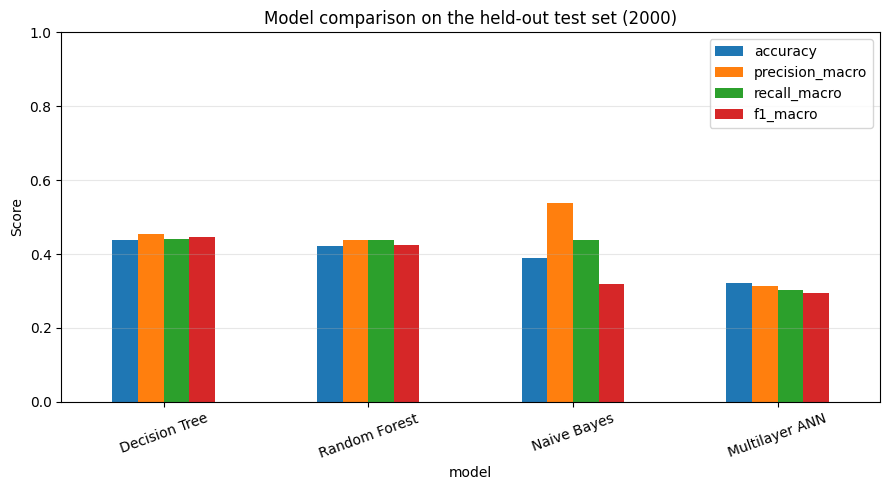

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
results[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(kind="bar", rot=20, ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison on the held-out test set (2000)")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_model_comparison.png", dpi=200)
plt.show()

## 3. Reading the comparison

Write your team's own interpretation here once you've looked at the numbers together, but the
groundwork from the earlier notebooks gives you a defensible starting point:

- **Random Forest and Decision Tree** are the strongest and most consistent performers, which
  fits — this is a small, structured, tabular dataset where tree-based splits on individual
  features (mostly density and warming, per the mutual-information ranking) are a natural fit,
  and Random Forest's averaging over many trees gives it a small, expected edge over a single
  Decision Tree.
- **Naive Bayes** has the highest macro-precision but the lowest macro-F1 and near-zero recall on
  "Medium" — it isn't a weaker model in some vague sense, it is being pulled down by a specific,
  identifiable cause: its independence assumption blurs the decision boundary hardest in the
  middle of a three-way ordinal split, exactly where "Medium" sits.
- **The Multilayer ANN** performs worst here, which is a genuinely expected result for a network
  trained on only 221 independent countries (repeated across three decades) rather than a
  failure of implementation — neural networks generally need substantially more data than
  tree-based models to find stable weights, and this was flagged as a likely outcome before the
  model was even trained (see `04_deep_learning_ann.ipynb`, Section 2).

**For the presentation:** the honest, defensible conclusion is that tree-based models suit this
particular dataset size and structure best, and that result — including the ANN
underperforming — is itself worth explaining rather than treating as a shortfall to hide.